<center>
<h1> Credit Risk Analytics
</center>

###### Definition of Target and Outcome Window:
One of the leading banks would like to predict bad customer while customer applying for loan. This model also called as PD Models (Probability of Default)


###### Data Pre-Processing - 
    - Missing Values Treatment - Numerical (Mean/Median imputation) and Categorical (Separate Missing Category or Merging)
    - Univariate Analysis - Outlier and Frequency Analysis
###### Data Exploratory Analysis
    - Bivariate Analysis - Numeric(TTest) and Categorical(Chisquare)
    - Bivariate Analysis - Visualization
    - Variable Transformation - P-Value based selection
    - Variable Transformation - Bucketing / Binning for numerical variables and Dummy for Categorical Variables
    - Variable Reduction - IV / Somers'D
    - Variable Reduction - Multicollinearity
###### Model Build and Model Diagnostics
    - Train and Test split
    - Significance of each Variable
    - Gini and ROC / Concordance analysis - Rank Ordering
    - Classification Table Analysis - Accuracy

###### Model Validation
    - OOS validation - p-value and sign testing for the model coefficients
    - Diagnostics check to remain similar to Training Model build
    - BootStrapping, if necessary
###### Model Interpretation for its properties
    - Inferencing for finding the most important contributors
    - Prediction of risk and proactive prevention by targeting segments of the population

#### import the packages

In [47]:
# import the packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression

In [48]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, accuracy_score

#### data import

In [49]:
# import the data under consideration
bankloans = pd.read_csv('D:/SampleData/bankloans.csv' )

#### UDFs

In [50]:
def continuous_var_summary( x ):
    
    # freq and missings
    n_total = x.shape[0]
    n_miss = x.isna().sum()
    perc_miss = n_miss * 100 / n_total
    
    # outliers - iqr
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lc_iqr = q1 - 1.5 * iqr
    uc_iqr = q3 + 1.5 * iqr
    
    
    return pd.Series( [ x.dtype, x.nunique(), n_total, x.count(), n_miss, perc_miss,
                       x.sum(), x.mean(), x.std(), x.var(), 
                       lc_iqr, uc_iqr, 
                       x.min(), x.quantile(0.01), x.quantile(0.05), x.quantile(0.10), 
                       x.quantile(0.25), x.quantile(0.5), x.quantile(0.75), 
                       x.quantile(0.90), x.quantile(0.95), x.quantile(0.99), x.max() ], 
                     
                    index = ['dtype', 'cardinality', 'n_tot', 'n', 'nmiss', 'perc_miss',
                             'sum', 'mean', 'std', 'var',
                        'lc_iqr', 'uc_iqr',
                        'min', 'p1', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99', 'max']) 

In [51]:
# Create Data audit Report for categorical variables
def categorical_var_summary(x):
    Mode = x.value_counts().sort_values(ascending = False)[0:1].reset_index()
    return pd.Series([x.count(), x.isnull().sum(), Mode.iloc[0, 0], Mode.iloc[0, 1], 
                          round(Mode.iloc[0, 1] * 100/x.count(), 2)], 
                  index = ['N', 'NMISS', 'MODE', 'FREQ', 'PERCENT'])

In [52]:
# Missing value imputation for categorical and continuous variables
def missing_imputation(x, stats = 'mean'):
    if (x.dtypes == 'float64') | (x.dtypes == 'int64'):
        x = x.fillna(x.mean()) if stats == 'mean' else x.fillna(x.median())
    return x

#### data inspection

In [53]:
# check the metadata
bankloans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


In [54]:
bankloans.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [55]:
bankloans.default.value_counts() / bankloans.default.notna().sum()

0.0    0.738571
1.0    0.261429
Name: default, dtype: float64

#### seperate out the data for existing and the new customers

In [56]:
# separate the new and existing customers
bankloans_existing = bankloans.loc[ bankloans.default.notna() ]
bankloans_new = bankloans.loc[ bankloans.default.isna() ]

In [57]:
bankloans_existing.shape

(700, 9)

In [58]:
# EDA for all the variables
bankloans_existing.apply( continuous_var_summary )

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
dtype,int64,int64,int64,int64,int64,float64,float64,float64,float64
cardinality,37,5,32,31,114,231,695,699,2
n_tot,700,700,700,700,700,700,700,700,700
n,700,700,700,700,700,700,700,700,700
nmiss,0,0,0,0,0,0,0,0,0
perc_miss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sum,24402,1206,5872,5795,31921,7182.4,1087.486972,2140.746028,183.0
mean,34.86,1.722857,8.388571,8.278571,45.601429,10.260571,1.553553,3.058209,0.261429
std,7.997342,0.928206,6.658039,6.824877,36.814226,6.827234,2.117197,3.287555,0.439727
var,63.957482,0.861566,44.329483,46.578939,1355.287265,46.611118,4.482523,10.808015,0.19336


#### data prepration/data cleaning

In [59]:
# outlier treatment
bankloans_existing = bankloans_existing.apply( lambda x: x.clip(lower = x.quantile(0.01), 
                                                                upper = x.quantile(0.99)) )

In [60]:
# Handling missings
# bankloans_existing = bankloans_existing.apply(lambda x: missing_imputation(x))

#### bi variate analysis to identify corr 

In [61]:
# correlation matrix
corr_matrix = bankloans_existing.corr()
# corr_matrix.to_csv('corr.csv')

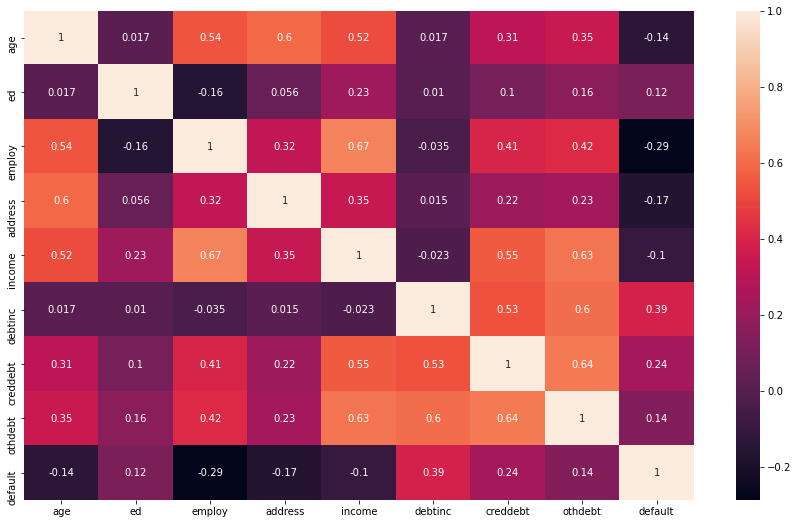

In [62]:
# visualize correlation matrix in Seaborn using a heatmap
plt.figure(figsize = (15, 9))
sns.heatmap(bankloans_existing.corr(), annot = True)
plt.show()

### Building logistic Regression Model

In [ ]:
# Train and Test split
train, test = train_test_split( bankloans_existing, test_size = 0.3, random_state =  42  # random state makes sure that you will always get same observations in training and testing data.

In [64]:
# print the columns
train.columns

Index(['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt',
       'othdebt', 'default'],
      dtype='object')

In [65]:
model_eq = 'default ~ ' + ' + '.join( train.columns.difference(['default']) )
model_eq

'default ~ address + age + creddebt + debtinc + ed + employ + income + othdebt'

In [66]:
# execute a model for the X variables
m1 = smf.logit( formula = model_eq, data = train ).fit() 

Optimization terminated successfully.
         Current function value: 0.425391
         Iterations 7


In [67]:
# print the model summary stats 
print(m1.summary2())

                         Results: Logit
Model:              Logit            Pseudo R-squared: 0.275     
Dependent Variable: default          AIC:              434.8834  
Date:               2022-07-09 11:04 BIC:              472.6330  
No. Observations:   490              Log-Likelihood:   -208.44   
Df Model:           8                LL-Null:          -287.47   
Df Residuals:       481              LLR p-value:      4.0651e-30
Converged:          1.0000           Scale:            1.0000    
No. Iterations:     7.0000                                       
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept     -1.3844    0.7360  -1.8808  0.0600  -2.8270   0.0582
address       -0.0853    0.0258  -3.3063  0.0009  -0.1359  -0.0348
age            0.0389    0.0202   1.9237  0.0544  -0.0007   0.0784
creddebt       0.6410    0.138

#### Data Exploratory Analysis
    - Variable Reduction using Somer's D values
    - Bi-variate analysis technique to check the predictive power of each independent against dependent
    - cutoff is 0.2 or 20% below which the variable is insignificant

#### get the Somer's D values for all the X variables

In [ ]:
from sklearn.metrics import roc_auc_score # receiver operating characteristics area under the score

In [69]:
# emplty dataframe to store the information
df = pd.DataFrame()

# iterate on each X variable
for var_name in bankloans_existing.columns.difference(['default']):
    
    # build the bivariate model and fit
    model = smf.logit( formula = 'default ~ ' + var_name, data = bankloans_existing ).fit()
    
    # predict the y
    y_predicted = model.predict( bankloans_existing )
    
    # get the roc_auc_score
    roc_score = roc_auc_score( bankloans_existing.default, y_predicted )
    
    # Get the Somar's D value
    somars_d = 2 * roc_score - 1
    
    # store the data in temp df
    temp_df = pd.DataFrame( [var_name, roc_score, somars_d ]).T
    
    # concat the data with the output dataframe
    df = pd.concat([df, temp_df], axis = 0)
    
# add the coilumn names
df.columns = ['Feature', 'ROC_AUC_SCORE', 'SomarsD']

Optimization terminated successfully.
         Current function value: 0.559856
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.564673
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.548956
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.501389
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.567774
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.527166
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.569055
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.565619
         Iterations 5


In [70]:
df

,Feature,ROC_AUC_SCORE,SomarsD
0,address,0.611192,0.222384
0,age,0.603165,0.206329
0,creddebt,0.636189,0.272378
0,debtinc,0.735253,0.470506
0,ed,0.574151,0.148302
0,employ,0.704569,0.409138
0,income,0.600136,0.200273
0,othdebt,0.586903,0.173806


In [71]:
features = list( df.loc[ df.SomarsD >= 0.2, 'Feature' ] )

In [72]:
features

['address', 'age', 'creddebt', 'debtinc', 'employ', 'income']

#### VIF - Variance Inflation Factor

0 - 5 => Ideal set of values
5-10 => Can work with them
>10 => Discard

In [73]:
# run the dmatrices
equation = 'default ~ ' + ' + '.join( features)

a, b = dmatrices( equation, data = bankloans_existing, return_type = 'dataframe')

# get the VIF
vif = pd.DataFrame()
vif["features"] = b.columns
vif["VIF Factor"] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]

vif

,features,VIF Factor
0,Intercept,28.286222
1,address,1.559236
2,age,2.036933
3,creddebt,2.564921
4,debtinc,1.778339
5,employ,1.997947
6,income,2.601717


### Build the actual model

In [74]:
features

['address', 'age', 'creddebt', 'debtinc', 'employ', 'income']

In [75]:
model_eq = 'default ~ ' + ' + '.join( features )
m2 = smf.logit( model_eq, data = train ).fit()
print( m2.summary2() )

Optimization terminated successfully.
         Current function value: 0.426980
         Iterations 7
                         Results: Logit
Model:              Logit            Pseudo R-squared: 0.272     
Dependent Variable: default          AIC:              432.4402  
Date:               2022-07-09 11:04 BIC:              461.8010  
No. Observations:   490              Log-Likelihood:   -209.22   
Df Model:           6                LL-Null:          -287.47   
Df Residuals:       483              LLR p-value:      3.2536e-31
Converged:          1.0000           Scale:            1.0000    
No. Iterations:     7.0000                                       
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept     -1.7966    0.5987  -3.0008  0.0027  -2.9701  -0.6232
address       -0.0849    0.0257  -3.3082  0.0009  -0.1351  -0.

In [76]:
features = ['address', 'age', 'creddebt', 'debtinc', 'employ']

model_eq = 'default ~ ' + ' + '.join( features )
m3 = smf.logit( model_eq, data = train ).fit()
print( m3.summary2() )

Optimization terminated successfully.
         Current function value: 0.427051
         Iterations 7
                         Results: Logit
Model:              Logit            Pseudo R-squared: 0.272     
Dependent Variable: default          AIC:              430.5102  
Date:               2022-07-09 11:04 BIC:              455.6766  
No. Observations:   490              Log-Likelihood:   -209.26   
Df Model:           5                LL-Null:          -287.47   
Df Residuals:       484              LLR p-value:      5.6901e-32
Converged:          1.0000           Scale:            1.0000    
No. Iterations:     7.0000                                       
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept     -1.7615    0.5836  -3.0185  0.0025  -2.9053  -0.6177
address       -0.0839    0.0254  -3.3047  0.0010  -0.1336  -0.

### predict the values

In [77]:
# predict the values on training and testing
train_predict = m3.predict(train)
test_predict = m3.predict(test)

In [78]:
train_predict.head(2)

357    0.585803
649    0.529728
dtype: float64

- p (Default = 1) = exp(LE) / (1 + exp(LE)) 

#### model scoring

In [86]:
# combine the y actual and y predicted
train_data = pd.concat([train.default, train_predict], axis = 1)
test_data = pd.concat([test.default, test_predict], axis = 1)

train_data.columns = ['y_actual', 'y_pred_proba']
test_data.columns = ['y_actual', 'y_pred_proba']

In [87]:
# roc_auc_score
from sklearn.metrics import roc_auc_score
concordance_train = roc_auc_score( train_data.y_actual, train_data.y_pred_proba )
concordance_test = roc_auc_score( test_data.y_actual, test_data.y_pred_proba )

print('Train:', concordance_train, '| Test: ', concordance_test)

Train: 0.838210632232098 | Test:  0.8885790340981113


#### find the model accuracy at cutoff 0.5

In [91]:
train_data['y_pred'] = np.where( train_data.y_pred_proba >= 0.5, 1, 0 )

In [94]:
# confusion matrix - Method 1
pd.crosstab( train_data.y_actual, train_data.y_pred ).loc[::-1, ::-1]

y_pred,1,0
y_actual,,
1.0,63,71
0.0,30,326


In [95]:
# confusion matrix - Method 2
from sklearn.metrics import confusion_matrix, classification_report

In [110]:
cm_p50 = confusion_matrix( train_data.y_actual, train_data.y_pred )[::-1, ::-1]

tp = cm_p50[0, 0]
tn = cm_p50[1, 1]
fp = cm_p50[1, 0]
fn = cm_p50[0, 1]

accuracy = (tp + tn) / cm_p50.sum()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(cm_p50)
print('accuracy: ', accuracy, '| tpr: ', tpr, '| fpr: ', fpr )

[[ 63  71]
 [ 30 326]]
accuracy:  0.7938775510204081 | tpr:  0.4701492537313433 | fpr:  0.08426966292134831


In [113]:
print( classification_report(train_data.y_actual, train_data.y_pred) )

              precision    recall  f1-score   support

         0.0       0.82      0.92      0.87       356
         1.0       0.68      0.47      0.56       134

    accuracy                           0.79       490
   macro avg       0.75      0.69      0.71       490
weighted avg       0.78      0.79      0.78       490



#### get the best cutoff  

In [117]:
pd.DataFrame([1, 2, 3]).T

,0,1,2
0,1,2,3


In [131]:
# empty dataframe to store the information
cm_scores = pd.DataFrame()

# run the loop for different proba values
for prob_val in np.arange( 0, 1.01, 0.01 ):
    
    # get the y_pred
    train_data['y_pred'] = np.where( train_data.y_pred_proba >= prob_val, 1, 0 )
    
    # get the confusion matrix
    cm = confusion_matrix( train_data.y_actual, train_data.y_pred )[::-1, ::-1]

    # get the metric values
    tp = cm[0, 0]
    tn = cm[1, 1]
    fp = cm[1, 0]
    fn = cm[0, 1]

    accuracy = (tp + tn) / cm.sum()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    s_s = tpr + 1 - fpr
    
    # store the data in temp dataframe
    temp_df = pd.DataFrame([prob_val, tp, tn, fp, fn, accuracy, tpr, fpr, s_s]).T
    
    # add the data to final dataframe
    cm_scores = pd.concat([cm_scores, temp_df], axis = 0 )
    
# add the column names
cm_scores.columns = ['prob_val', 'tp', 'tn', 'fp', 'fn', 'accuracy', 'tpr', 'fpr', 's_s']

# get the best cutoff
best_cutoff = cm_scores.loc[ cm_scores.s_s == cm_scores.s_s.max(), 'prob_val'][0]
print('best_cutoff: ', best_cutoff)

best_cutoff:  0.34


#### final predictions at best cutoff

In [133]:
train_data['y_pred'] = np.where( train_data.y_pred_proba >= best_cutoff, 1, 0 )
test_data['y_pred'] = np.where( test_data.y_pred_proba >= best_cutoff, 1, 0 )

#### classification report at best cutoff

In [136]:
print(classification_report( train_data.y_actual, train_data.y_pred ))
print('-------------------------------------------------------------')
print(classification_report( test_data.y_actual, test_data.y_pred ))

              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84       356
         1.0       0.57      0.74      0.64       134

    accuracy                           0.78       490
   macro avg       0.73      0.76      0.74       490
weighted avg       0.80      0.78      0.78       490

-------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.91      0.85      0.88       161
         1.0       0.60      0.73      0.66        49

    accuracy                           0.82       210
   macro avg       0.76      0.79      0.77       210
weighted avg       0.84      0.82      0.83       210



### Decile Analysis

In [ ]:
#Decile analysis
#Top-two deciles - High risk customers - will reject applications
#3rd,4th, 5th deciesl - medium risk customers - will accept application with proper scrutiny
#6th decile onwards - low risk customers - accept the application

In [137]:
# Decile analysis for validation of models - Business validation
train_data['Deciles'] = pd.qcut( train_data.y_pred_proba, 10, labels = False)
test_data['Deciles'] = pd.qcut( test_data.y_pred_proba, 10, labels = False)

#### Decile Analysis for train data

In [138]:
train_data.head(2)

,y_actual,y_pred_proba,y_pred,Deciles
357,1.0,0.585803,1,8
649,0.0,0.529728,1,8


In [144]:
train_deciles = train_data.groupby('Deciles')[['y_pred_proba', 'y_actual']].agg( {'y_pred_proba' : ['min', 'max'], 
        'y_actual' : ['sum', 'count']} ).reset_index().sort_values(by = 'Deciles', ascending = False)

In [145]:
test_deciles = test_data.groupby('Deciles')[['y_pred_proba', 'y_actual']].agg( {'y_pred_proba' : ['min', 'max'], 
        'y_actual' : ['sum', 'count']} ).reset_index().sort_values(by = 'Deciles', ascending = False)

In [146]:
train_deciles

Deciles y_pred_proba           y_actual      
                   min       max      sum count
9       9     0.629780  0.986816     37.0    49
8       8     0.492289  0.625658     29.0    49
7       7     0.396660  0.491821     18.0    49
6       6     0.289372  0.396070     19.0    49
5       5     0.215034  0.288422     15.0    49
4       4     0.144435  0.211515      6.0    49
3       3     0.084038  0.143758      5.0    49
2       2     0.040619  0.083720      3.0    49
1       1     0.013535  0.040588      2.0    49
0       0     0.001349  0.012572      0.0    49

In [147]:
test_deciles

Deciles y_pred_proba           y_actual      
                   min       max      sum count
9       9     0.677376  0.972221     19.0    21
8       8     0.491667  0.674228     12.0    21
7       7     0.320771  0.481541      5.0    21
6       6     0.254996  0.312851      5.0    21
5       5     0.168005  0.241181      4.0    21
4       4     0.117243  0.166776      1.0    21
3       3     0.066399  0.116729      2.0    21
2       2     0.040592  0.065938      1.0    21
1       1     0.017485  0.037297      0.0    21
0       0     0.000842  0.016229      0.0    21

In [148]:
# export the data in the csv files
train_deciles.to_csv('D:/train_deciles.csv')
test_deciles.to_csv('D:/test_deciles.csv')

## Predicting new customers (Implementation of Model on new data)

In [149]:
# predciting new customers good or bad
bankloans_new.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
700,36,1,16,13,32,10.9,0.544128,2.943872,NaN
701,50,1,6,27,21,12.9,1.316574,1.392426,NaN
702,40,1,9,9,33,17.0,4.880700,0.729300,NaN
703,31,1,5,7,23,2.0,0.046000,0.414000,NaN
704,29,1,4,0,24,7.8,0.866736,1.005264,NaN


#### before scoring new customers, you need to process the data using the sames steps you followed while building the model

In [150]:
bankloans_new.loc[:, 'prob'] = m3.predict( bankloans_new )

C:\Users\DELL\anaconda3\lib\site-packages\pandas\core\indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
C:\Users\DELL\anaconda3\lib\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [151]:
bankloans_new.loc[:, 'default'] = bankloans_new['prob'].apply(lambda x: 1 if x > 0.34 else 0)

In [152]:
bankloans_new.default.value_counts()

0    107
1     43
Name: default, dtype: int64

In [153]:
bankloans_new.sort_values( 'prob', ascending = False )

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,prob
803,48,1,10,0,70,28.2,10.679340,9.060660,1,0.997485
840,35,2,11,1,62,32.4,9.702504,10.385496,1,0.992220
810,26,4,1,6,64,23.3,7.754240,7.157760,1,0.991865
716,26,4,1,5,92,13.0,6.506240,5.453760,1,0.967938
836,41,2,13,1,93,14.7,9.542358,4.128642,1,0.961655
...,...,...,...,...,...,...,...,...,...,...
728,39,1,19,16,53,3.7,0.190217,1.770783,0,0.002405
742,44,4,18,23,78,1.0,0.564720,0.215280,0,0.002167
749,48,2,21,14,86,1.2,0.145512,0.886488,0,0.001985
723,52,1,33,23,139,5.6,2.288496,5.495504,0,0.000256


#### We are rejecting applications for 43 customers based on cut-off = 0.34

In [163]:
%matplotlib?

In [169]:
%matplotlib inline

C:\Users\DELL\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<IPython.core.display.Javascript object>


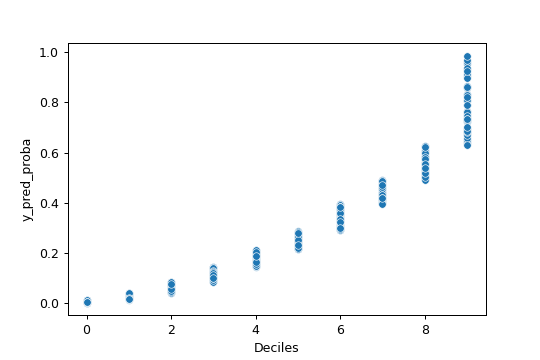

<AxesSubplot:xlabel='Deciles', ylabel='y_pred_proba'>

In [168]:
sns.scatterplot(train_data.Deciles, train_data.y_pred_proba)